<a href="https://colab.research.google.com/github/L-Carlos/aulas-machine-learning/blob/main/analytics_descriptive_predictive_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import matplotlib.pyplot as plt

from multiprocessing import cpu_count

from sklearn.linear_model import Perceptron
from sklearn.model_selection import cross_val_score, train_test_split
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.utils import to_categorical

In [2]:
seed = 2026
np.random.seed(seed)

nb_samples = 1000           # 1000 amostras
nsb = int(nb_samples / 4)   # 4 grupos

X = np.zeros((nb_samples, 2)) # 2 dimensoes
Y = np.zeros((nb_samples, )) # classes roxo = 1, amarelo = 0

# coordenadas 1, -1
X[0:nsb, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 0.0

# coordenadas 1, 1
X[nsb:(2 * nsb), :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2 * nsb)] = 1.0

# coordenadas -1, 1
X[(2 * nsb):(3 * nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2 * nsb):(3 * nsb)] = 0.0

# coordenadas -1, -1
X[(3 * nsb):, :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3 * nsb):] = 1.0

std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)

X, Y = shuffle(X, Y, random_state=seed)


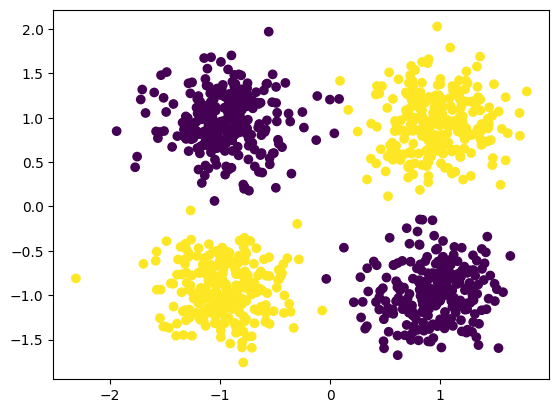

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

In [4]:
pc = Perceptron(penalty="l2", alpha=0.1, max_iter=1000, n_jobs=cpu_count(), random_state=seed)

print(f"{np.mean(cross_val_score(pc, X, Y, cv=10)):.3f}")

0.535


In [5]:
def make_meshgrid(x, y, h=0.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() -1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)

    return out

def plot_model(clf):
    fig, ax = plt.subplots()
    title = ("Superficie de Decisão")

    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1)

    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_title(title)

    plt.show()

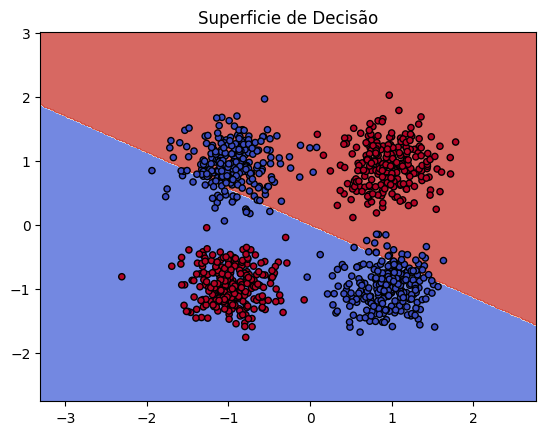

In [6]:
pc.fit(X, Y)
plot_model(pc)

In [7]:
model = Sequential()

model.add(Dense(4, input_dim=2))
model.add(Activation("tanh"))

model.add(Dense(2))
model.add(Activation("softmax"))

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
test_size = 0.3

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [12]:
model.fit(
    X_train, to_categorical(Y_train, num_classes=2),
    epochs=100, batch_size=32,
    validation_data=(X_test, to_categorical(Y_test, num_classes=2)))

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5714 - loss: 0.6906 - val_accuracy: 0.5567 - val_loss: 0.6907
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6543 - loss: 0.6847 - val_accuracy: 0.6333 - val_loss: 0.6856
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7086 - loss: 0.6797 - val_accuracy: 0.6800 - val_loss: 0.6803
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7271 - loss: 0.6744 - val_accuracy: 0.6933 - val_loss: 0.6757
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7329 - loss: 0.6691 - val_accuracy: 0.7000 - val_loss: 0.6706
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7371 - loss: 0.6638 - val_accuracy: 0.7033 - val_loss: 0.6656
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7357 - loss: 0.6580 - val_accuracy: 0.7033 - val_loss: 0.6599
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7300 - loss: 0.6520 - val_accuracy: 0.7033 - 

In [13]:
Y_eval_mlp = np.argmax(model.predict(X_test), axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


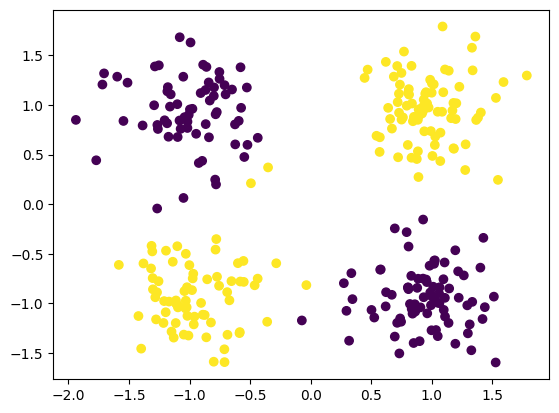

In [14]:
plt.scatter(X_test[:,0], X_test[:,1], c=Y_eval_mlp)
plt.show()

In [15]:
Xm = np.linspace(-2.0, 2.0, nb_samples)
Ym = np.linspace(-2.0, 2.0, nb_samples)
Xmg, Ymg = np.meshgrid(Xm, Ym)
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1)

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step


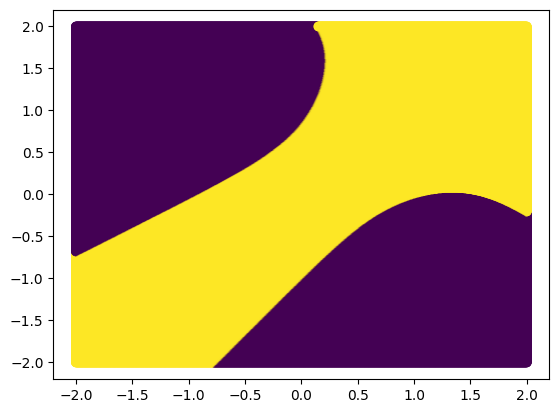

In [16]:
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp)
plt.show()

In [17]:
model = Sequential()

model.add(Dense(4, input_dim=2))
model.add(Activation("relu"))

model.add(Dense(2))
model.add(Activation("softmax"))

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

model.fit(
    X_train, to_categorical(Y_train, num_classes=2),
    epochs=100,
    batch_size=32,
    validation_data=(X_test, to_categorical(Y_test, num_classes=2))
    )

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5043 - loss: 0.5767 - val_accuracy: 0.4900 - val_loss: 0.5719
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5257 - loss: 0.5477 - val_accuracy: 0.5467 - val_loss: 0.5421
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5971 - loss: 0.5216 - val_accuracy: 0.6800 - val_loss: 0.5150
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7300 - loss: 0.4978 - val_accuracy: 0.7667 - val_loss: 0.4903
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8014 - loss: 0.4760 - val_accuracy: 0.8367 - val_loss: 0.4673
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8543 - loss: 0.4554 - val_accuracy: 0.8867 - val_loss: 0.4468
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8871 - loss: 0.4364 - val_accuracy: 0.9000 - val_loss: 0.4282
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9043 - loss: 0.4189 - val_accuracy: 0.9233 - 

In [19]:
Y_eval_mlp = np.argmax(model.predict(X_test), axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


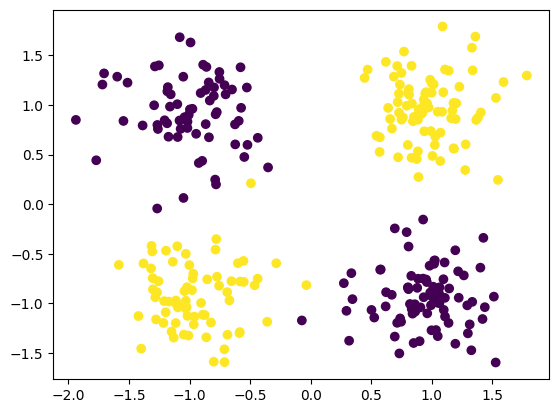

In [20]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_eval_mlp)
plt.show()


In [21]:
Xm = np.linspace(-2.0, 2.0, nb_samples)
Ym = np.linspace(-2.0, 2.0, nb_samples)
Xmg, Ymg = np.meshgrid(Xm, Ym)
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1)

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step


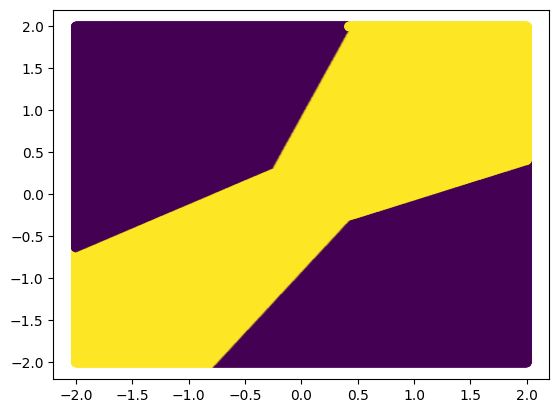

In [22]:
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp)
plt.show()